In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib.font_manager as font_manager

In [4]:
font_path = "/home/z3536241/Fonts/arial.ttf"
font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name

plt.rcParams['svg.fonttype'] = 'none'

## load layouts and check via plotting

In [5]:
Experiment1Layout = pd.read_csv("/home/z3536241/src/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/mACmChPOLR2A_TotalPolII/241021_mACmChPOLR2A_TotalPolII/METADATA/241021_mACmChPOLR2A_TotalPolII.csv")
Experiment2Layout = pd.read_csv("/home/z3536241/src/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/mACmChPOLR2A_TotalPolII/241026_mACmChPOLR2A_TotalPolII/METADATA/241026_mACmChPOLR2A_TotalPolII.csv")
Experiment3Layout = pd.read_csv("/home/z3536241/src/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/mACmChPOLR2A_TotalPolII/241102_mACmChPOLR2A_TotalPolII/METADATA/241102_mACmChPOLR2A_TotalPolII.csv")

## load quantifcation files and assemble as individual dataframes

In [8]:
Experiment1_Quantification_Directory = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/241025/211024_mACmChPOLR2A_TotalPolII/20241025_170819_473/QUANTIFICATION")
Experiment1_Quantification_Files = glob.glob(str(Experiment1_Quantification_Directory / "*.csv"))

Experiment1_Cycle2_Quantification_Directory = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/241028/211024_mACmChPOLR2A_TotalPolII/20241027_213225_340/QUANTIFICATION")
Experiment1_Cycle2_Quantification_Files = glob.glob(str(Experiment1_Cycle2_Quantification_Directory / "*.csv"))

Experiment2_Quantification_Directory = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/241026_mACmChPOLR2A_TotalPolII/20241031_181448_440/QUANTIFICATION/")
Experiment2_Quantification_Files = glob.glob(str(Experiment2_Quantification_Directory / "*.csv"))

Experiment3_Quantification_Directory = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/241102_mACmChPOLR2A_TotalPolII/20241106_161810_844/QUANTIFICATION/")
Experiment3_Quantification_Files = glob.glob(str(Experiment3_Quantification_Directory / "*.csv"))

len(Experiment1_Quantification_Files), len(Experiment1_Cycle2_Quantification_Files), len(Experiment2_Quantification_Files), len(Experiment3_Quantification_Files)

(960, 956, 952, 956)

In [10]:
qdfs = list()


for f in tqdm(Experiment1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment1_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment1_PerCell['well'] = wellnames

fovs = [f[40:44] for f in files]
Experiment1_PerCell['fov'] = fovs

Experiment1_Intensities = pd.DataFrame({
    "WELL" : Experiment1_PerCell['well'],
    "IF_647_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_647'],
    "GFP_488_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment1_PerCell['Nuclei_area']
})

100%|██████████| 960/960 [00:02<00:00, 420.53it/s]


In [12]:
qdfs = list()


for f in tqdm(Experiment1_Cycle2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_PerCell_Cycle2 = pd.concat(qdfs, ignore_index=True)

files = Experiment1_PerCell_Cycle2['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment1_PerCell_Cycle2['well'] = wellnames

fovs = [f[40:44] for f in files]
Experiment1_PerCell_Cycle2['fov'] = fovs

Experiment1_Intensities_Cycle2 = pd.DataFrame({
    "WELL" : Experiment1_PerCell_Cycle2['well'],
    "RFP_561_Intensity" : Experiment1_PerCell_Cycle2['Nuclei_intensity_mean_561']
})

100%|██████████| 956/956 [00:17<00:00, 55.37it/s] 


In [13]:
qdfs = list()


for f in tqdm(Experiment2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment2_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment2_PerCell['well'] = wellnames

fovs = [f[40:44] for f in files]
Experiment2_PerCell['fov'] = fovs

Experiment2_Intensities = pd.DataFrame({
    "WELL" : Experiment2_PerCell['well'],
    "IF_647_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_647'],
    "RFP_561_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_561'],
    "GFP_488_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment2_PerCell['Nuclei_area']
})

100%|██████████| 952/952 [00:21<00:00, 44.98it/s]


In [14]:
qdfs = list()


for f in tqdm(Experiment3_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment3_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment3_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment3_PerCell['well'] = wellnames

fovs = [f[40:44] for f in files]
Experiment3_PerCell['fov'] = fovs

Experiment3_Intensities = pd.DataFrame({
    "WELL" : Experiment3_PerCell['well'],
    "IF_647_Intensity" : Experiment3_PerCell['Nuclei_intensity_mean_647'],
    "RFP_561_Intensity" : Experiment3_PerCell['Nuclei_intensity_mean_561'],
    "GFP_488_Intensity" : Experiment3_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment3_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment3_PerCell['Nuclei_area']
})

100%|██████████| 956/956 [00:19<00:00, 50.26it/s]


In [21]:
CountsByWell1 = Experiment1_Intensities.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell1.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment1 = Experiment1_Intensities.groupby('WELL').mean().reset_index().merge(Experiment1Layout, how = 'left')
IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.merge(CountsByWell1, how = 'left')
IntensitiesByWell_Experiment1['EXPERIMENT'] = '251021_mACmChPOLR2A_TotalPolII'

Experiment1_Intensities_Cycle2_ByWell = Experiment1_Intensities_Cycle2.groupby('WELL').mean().reset_index()
IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.merge(Experiment1_Intensities_Cycle2_ByWell)

In [22]:
CountsByWell2 = Experiment2_Intensities.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment2 = Experiment2_Intensities.groupby('WELL').mean().reset_index().merge(Experiment2Layout, how = 'left')
IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.merge(CountsByWell2, how = 'left')
IntensitiesByWell_Experiment2['EXPERIMENT'] = '251026_mACmChPOLR2A_TotalPolII'

CountsByWell3 = Experiment3_Intensities.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell3.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment3 = Experiment3_Intensities.groupby('WELL').mean().reset_index().merge(Experiment3Layout, how = 'left')
IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3.merge(CountsByWell3, how = 'left')
IntensitiesByWell_Experiment3['EXPERIMENT'] = '251102_mACmChPOLR2A_TotalPolII'

## examine raw data per experiment

In [25]:
IntensitiesByWell_Experiment1.CELL.unique().tolist()

['HCT116 OsTIRF74G',
 'HCT116 mChPOLR2A Clone 2',
 'HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5',
 'HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1']

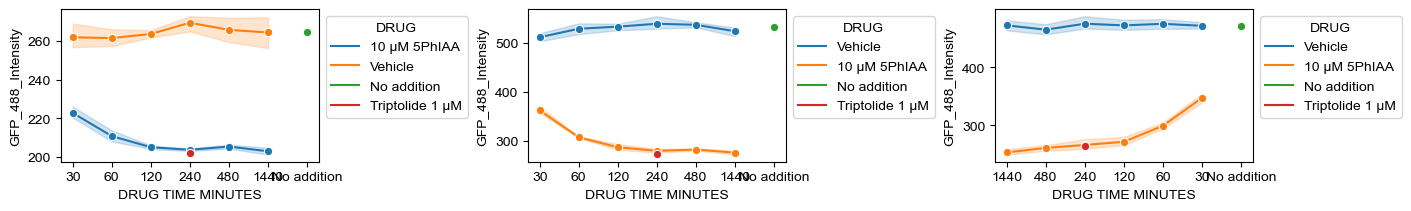

In [41]:
f, a = plt.subplots(ncols = 3, figsize = (14,2), layout = 'constrained')

h = sns.lineplot(IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'),
             x = 'DRUG TIME MINUTES',
             y = 'GFP_488_Intensity',
             hue = 'DRUG',
             marker = 'o',
             ax = a[0])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.lineplot(IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'),
             x = 'DRUG TIME MINUTES',
             y = 'GFP_488_Intensity',
             hue = 'DRUG',
             marker = 'o',
             ax = a[1])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.lineplot(IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'),
             x = 'DRUG TIME MINUTES',
             y = 'GFP_488_Intensity',
             hue = 'DRUG',
             marker = 'o',
             ax = a[2])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

In [39]:
IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle"')[IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle"')['DRUG TIME MINUTES'] == '240']

,WELL,IF_647_Intensity,RFP_561_Intensity,GFP_488_Intensity,DAPI_Intensity,NucleusArea,CELL,DRUG,DRUG TIME MINUTES,PRIMARY,SECONDARY,TotalNumberCells,EXPERIMENT
81,G04,708.317427,211.066561,533.039901,581.842668,1796.185039,HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1,Vehicle,240,Santa Cruz mouse anti-RPB1 (F12),Alexa647 goat anti-mouse,2032,251026_mACmChPOLR2A_TotalPolII
87,G10,678.918573,212.832793,528.272525,590.319740,1716.485881,HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1,Vehicle,240,Santa Cruz mouse anti-RPB1 (F12),Alexa647 goat anti-mouse,2054,251026_mACmChPOLR2A_TotalPolII
93,G16,583.679476,223.669518,293.132462,566.769156,1735.305627,HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1,Vehicle,240,Santa Cruz mouse anti-RPB1 (F12),Alexa647 goat anti-mouse,2346,251026_mACmChPOLR2A_TotalPolII
167,K10,681.481422,213.252299,553.521327,577.305623,1700.363682,HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1,Vehicle,240,Santa Cruz mouse anti-RPB1 (F12),Alexa647 goat anti-mouse,1999,251026_mACmChPOLR2A_TotalPolII


In [40]:
# well G16 in Experiment2 clear outlier, exclude, likely error in drug addition
IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('WELL != "G16"')

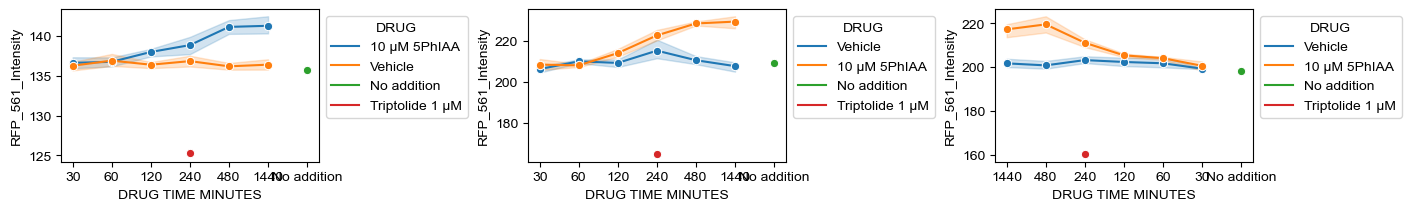

In [35]:
f, a = plt.subplots(ncols = 3, figsize = (14,2), layout = 'constrained')

h = sns.lineplot(IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'),
             x = 'DRUG TIME MINUTES',
             y = 'RFP_561_Intensity',
             hue = 'DRUG',
             marker = 'o',
             ax = a[0])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.lineplot(IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'),
             x = 'DRUG TIME MINUTES',
             y = 'RFP_561_Intensity',
             hue = 'DRUG',
             marker = 'o',
             ax = a[1])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.lineplot(IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'),
             x = 'DRUG TIME MINUTES',
             y = 'RFP_561_Intensity',
             hue = 'DRUG',
             marker = 'o',
             ax = a[2])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

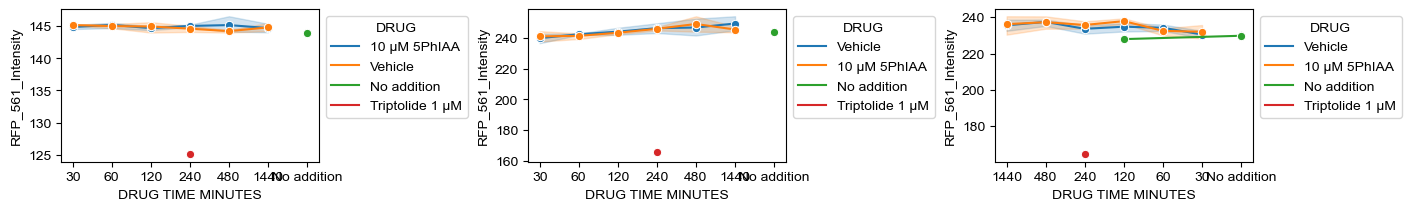

In [34]:
f, a = plt.subplots(ncols = 3, figsize = (14,2), layout = 'constrained')

h = sns.lineplot(IntensitiesByWell_Experiment1.query('CELL == "HCT116 mChPOLR2A Clone 2"'),
             x = 'DRUG TIME MINUTES',
             y = 'RFP_561_Intensity',
             hue = 'DRUG',
             marker = 'o',
             ax = a[0])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.lineplot(IntensitiesByWell_Experiment2.query('CELL == "HCT116 mChPOLR2A Clone 2"'),
             x = 'DRUG TIME MINUTES',
             y = 'RFP_561_Intensity',
             hue = 'DRUG',
             marker = 'o',
             ax = a[1])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.lineplot(IntensitiesByWell_Experiment3.query('CELL == "HCT116 mChPOLR2A Clone 2"'),
             x = 'DRUG TIME MINUTES',
             y = 'RFP_561_Intensity',
             hue = 'DRUG',
             marker = 'o',
             ax = a[2])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

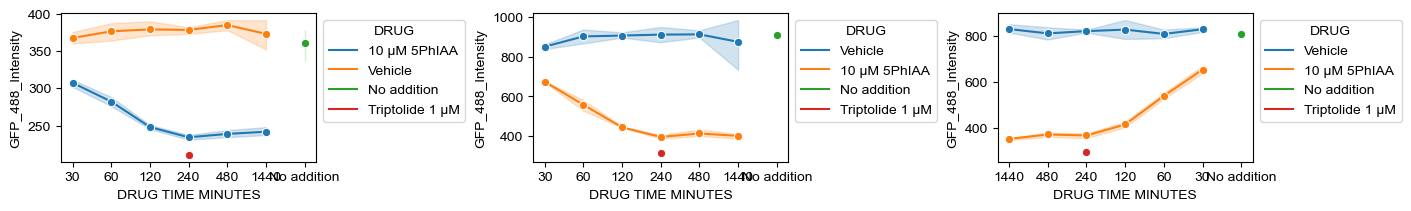

In [48]:
f, a = plt.subplots(ncols = 3, figsize = (14,2), layout = 'constrained')

h = sns.lineplot(IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5"'),
             x = 'DRUG TIME MINUTES',
             y = 'GFP_488_Intensity',
             hue = 'DRUG',
             marker = 'o',
             ax = a[0])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.lineplot(IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5"'),
             x = 'DRUG TIME MINUTES',
             y = 'GFP_488_Intensity',
             hue = 'DRUG',
             marker = 'o',
             ax = a[1])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.lineplot(IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5"'),
             x = 'DRUG TIME MINUTES',
             y = 'GFP_488_Intensity',
             hue = 'DRUG',
             marker = 'o',
             ax = a[2])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

In [47]:
IntensitiesByWell_Experiment2[IntensitiesByWell_Experiment2['DRUG TIME MINUTES'] == '1440'].query('CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5" & DRUG == "Vehicle"')

,WELL,IF_647_Intensity,RFP_561_Intensity,GFP_488_Intensity,DAPI_Intensity,NucleusArea,CELL,DRUG,DRUG TIME MINUTES,PRIMARY,SECONDARY,TotalNumberCells,EXPERIMENT
123,I06,534.012147,159.088852,733.611518,598.745381,1951.907186,HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5,Vehicle,1440,Santa Cruz mouse anti-RPB1 (F12),Alexa647 goat anti-mouse,1336,251026_mACmChPOLR2A_TotalPolII
129,I12,648.041682,159.593511,905.368372,607.634232,1842.297107,HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5,Vehicle,1440,Santa Cruz mouse anti-RPB1 (F12),Alexa647 goat anti-mouse,1417,251026_mACmChPOLR2A_TotalPolII
209,M12,651.279790,165.479258,983.984490,617.025591,1876.659361,HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5,Vehicle,1440,Santa Cruz mouse anti-RPB1 (F12),Alexa647 goat anti-mouse,1095,251026_mACmChPOLR2A_TotalPolII


In [46]:
# well I21 in Experiment2 clear outlier, exclude, likely error in drug addition
IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('WELL != "I21"')

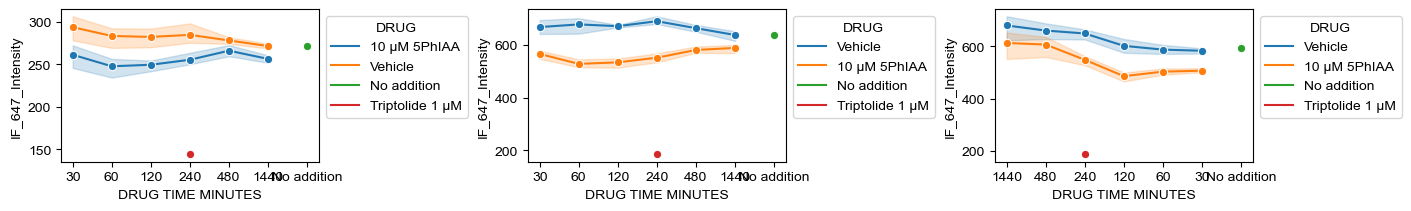

In [50]:
f, a = plt.subplots(ncols = 3, figsize = (14,2), layout = 'constrained')

h = sns.lineplot(IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'),
             x = 'DRUG TIME MINUTES',
             y = 'IF_647_Intensity',
             hue = 'DRUG',
             marker = 'o',
             ax = a[0])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.lineplot(IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'),
             x = 'DRUG TIME MINUTES',
             y = 'IF_647_Intensity',
             hue = 'DRUG',
             marker = 'o',
             ax = a[1])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.lineplot(IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'),
             x = 'DRUG TIME MINUTES',
             y = 'IF_647_Intensity',
             hue = 'DRUG',
             marker = 'o',
             ax = a[2])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

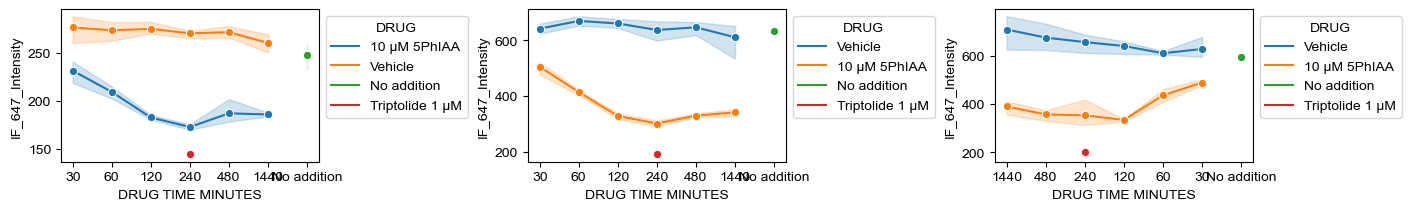

In [49]:
f, a = plt.subplots(ncols = 3, figsize = (14,2), layout = 'constrained')

h = sns.lineplot(IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5"'),
             x = 'DRUG TIME MINUTES',
             y = 'IF_647_Intensity',
             hue = 'DRUG',
             marker = 'o',
             ax = a[0])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.lineplot(IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5"'),
             x = 'DRUG TIME MINUTES',
             y = 'IF_647_Intensity',
             hue = 'DRUG',
             marker = 'o',
             ax = a[1])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.lineplot(IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5"'),
             x = 'DRUG TIME MINUTES',
             y = 'IF_647_Intensity',
             hue = 'DRUG',
             marker = 'o',
             ax = a[2])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

## background subtract and normalise across experiments

In [64]:
E1_GFP_Zero = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G"').GFP_488_Intensity.mean()
E2_GFP_Zero = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G"').GFP_488_Intensity.mean()
E3_GFP_Zero = IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G"').GFP_488_Intensity.mean()

IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment1['GFP_488_Intensity'] - E1_GFP_Zero
IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment2['GFP_488_Intensity'] - E2_GFP_Zero
IntensitiesByWell_Experiment3['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment3['GFP_488_Intensity'] - E3_GFP_Zero

E1_GFP_NV = IntensitiesByWell_Experiment1.query(   'CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5" & DRUG == "Vehicle"').GFP_Intensity_BGS.mean()
E2_GFP_NV = IntensitiesByWell_Experiment2.query(   'CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5" & DRUG == "Vehicle"').GFP_Intensity_BGS.mean()
E3_GFP_NV = IntensitiesByWell_Experiment3.query(   'CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5" & DRUG == "Vehicle"').GFP_Intensity_BGS.mean()


IntensitiesByWell_Experiment1['GFP_Intensity_FC'] = IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] / E1_GFP_NV
IntensitiesByWell_Experiment2['GFP_Intensity_FC'] = IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] / E2_GFP_NV
IntensitiesByWell_Experiment3['GFP_Intensity_FC'] = IntensitiesByWell_Experiment3['GFP_Intensity_BGS'] / E3_GFP_NV

In [62]:
E1_RFP_Zero = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G"').RFP_561_Intensity.mean()
E2_RFP_Zero = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G"').RFP_561_Intensity.mean()
E3_RFP_Zero = IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G"').RFP_561_Intensity.mean()

IntensitiesByWell_Experiment1['RFP_Intensity_BGS'] = IntensitiesByWell_Experiment1['RFP_561_Intensity'] - E1_RFP_Zero
IntensitiesByWell_Experiment2['RFP_Intensity_BGS'] = IntensitiesByWell_Experiment2['RFP_561_Intensity'] - E2_RFP_Zero
IntensitiesByWell_Experiment3['RFP_Intensity_BGS'] = IntensitiesByWell_Experiment3['RFP_561_Intensity'] - E3_RFP_Zero

E1_RFP_NV = IntensitiesByWell_Experiment1.query('CELL == "HCT116 mChPOLR2A Clone 2" & DRUG == "Vehicle"').RFP_Intensity_BGS.mean()
E2_RFP_NV = IntensitiesByWell_Experiment2.query('CELL == "HCT116 mChPOLR2A Clone 2" & DRUG == "Vehicle"').RFP_Intensity_BGS.mean()
E3_RFP_NV = IntensitiesByWell_Experiment3.query('CELL == "HCT116 mChPOLR2A Clone 2" & DRUG == "Vehicle"').RFP_Intensity_BGS.mean()

IntensitiesByWell_Experiment1['RFP_Intensity_FC'] = IntensitiesByWell_Experiment1['RFP_Intensity_BGS'] / E1_RFP_NV
IntensitiesByWell_Experiment2['RFP_Intensity_FC'] = IntensitiesByWell_Experiment2['RFP_Intensity_BGS'] / E2_RFP_NV
IntensitiesByWell_Experiment3['RFP_Intensity_FC'] = IntensitiesByWell_Experiment3['RFP_Intensity_BGS'] / E3_RFP_NV

In [71]:
IntensitiesByWell = pd.concat([IntensitiesByWell_Experiment1, IntensitiesByWell_Experiment2, IntensitiesByWell_Experiment3])

In [66]:
E1_IF_Zero = IntensitiesByWell_Experiment1.query('PRIMARY == "No primary"')['IF_647_Intensity'].mean()
E2_IF_Zero = IntensitiesByWell_Experiment2.query('PRIMARY == "No primary"')['IF_647_Intensity'].mean()
E3_IF_Zero = IntensitiesByWell_Experiment3.query('PRIMARY == "No primary"')['IF_647_Intensity'].mean()

IntensitiesByWell_Experiment1['IF_647_Intensity_BGS'] = IntensitiesByWell_Experiment1['IF_647_Intensity'] - E1_IF_Zero
IntensitiesByWell_Experiment2['IF_647_Intensity_BGS'] = IntensitiesByWell_Experiment2['IF_647_Intensity'] - E2_IF_Zero
IntensitiesByWell_Experiment3['IF_647_Intensity_BGS'] = IntensitiesByWell_Experiment3['IF_647_Intensity'] - E3_IF_Zero

In [67]:
mACmCh_Total_IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & PRIMARY == "Santa Cruz mouse anti-RPB1 (F12)"')
mACmCh_Total_IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & PRIMARY == "Santa Cruz mouse anti-RPB1 (F12)"')
mACmCh_Total_IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & PRIMARY == "Santa Cruz mouse anti-RPB1 (F12)"')

E1_mACmCh_Total_NV = mACmCh_Total_IntensitiesByWell_Experiment1.query('DRUG == "Vehicle"')['IF_647_Intensity_BGS'].mean()
E2_mACmCh_Total_NV = mACmCh_Total_IntensitiesByWell_Experiment2.query('DRUG == "Vehicle"')['IF_647_Intensity_BGS'].mean()
E3_mACmCh_Total_NV = mACmCh_Total_IntensitiesByWell_Experiment3.query('DRUG == "Vehicle"')['IF_647_Intensity_BGS'].mean()

mACmCh_Total_IntensitiesByWell_Experiment1['IF_647_Intensity_FC'] = mACmCh_Total_IntensitiesByWell_Experiment1['IF_647_Intensity_BGS'] / E1_mACmCh_Total_NV
mACmCh_Total_IntensitiesByWell_Experiment2['IF_647_Intensity_FC'] = mACmCh_Total_IntensitiesByWell_Experiment2['IF_647_Intensity_BGS'] / E2_mACmCh_Total_NV
mACmCh_Total_IntensitiesByWell_Experiment3['IF_647_Intensity_FC'] = mACmCh_Total_IntensitiesByWell_Experiment3['IF_647_Intensity_BGS'] / E3_mACmCh_Total_NV


/scratch/pbs.8262740.kman.restech.unsw.edu.au/ipykernel_89333/2306452819.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mACmCh_Total_IntensitiesByWell_Experiment1['IF_647_Intensity_FC'] = mACmCh_Total_IntensitiesByWell_Experiment1['IF_647_Intensity_BGS'] / E1_mACmCh_Total_NV
/scratch/pbs.8262740.kman.restech.unsw.edu.au/ipykernel_89333/2306452819.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mACmCh_Total_IntensitiesByWell_Experiment2['IF_647_Intensity_FC'] = mACmCh_Total_IntensitiesByWell_Experi

In [95]:
mACmCh_Total_IntensitiesByWell = pd.concat([mACmCh_Total_IntensitiesByWell_Experiment1, mACmCh_Total_IntensitiesByWell_Experiment2, mACmCh_Total_IntensitiesByWell_Experiment3])

In [113]:
mACPOLR2A_Total_IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5" & PRIMARY == "Santa Cruz mouse anti-RPB1 (F12)"')
mACPOLR2A_Total_IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5" & PRIMARY == "Santa Cruz mouse anti-RPB1 (F12)"')
mACPOLR2A_Total_IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5" & PRIMARY == "Santa Cruz mouse anti-RPB1 (F12)"')

E1_mACPOLR2A_Total_NV = mACPOLR2A_Total_IntensitiesByWell_Experiment1.query('DRUG == "Vehicle"')['IF_647_Intensity_BGS'].mean()
E2_mACPOLR2A_Total_NV = mACPOLR2A_Total_IntensitiesByWell_Experiment2.query('DRUG == "Vehicle"')['IF_647_Intensity_BGS'].mean()
E3_mACPOLR2A_Total_NV = mACPOLR2A_Total_IntensitiesByWell_Experiment3.query('DRUG == "Vehicle"')['IF_647_Intensity_BGS'].mean()

mACPOLR2A_Total_IntensitiesByWell_Experiment1['IF_647_Intensity_FC'] = mACPOLR2A_Total_IntensitiesByWell_Experiment1['IF_647_Intensity_BGS'] / E1_mACPOLR2A_Total_NV 
mACPOLR2A_Total_IntensitiesByWell_Experiment2['IF_647_Intensity_FC'] = mACPOLR2A_Total_IntensitiesByWell_Experiment2['IF_647_Intensity_BGS'] / E2_mACPOLR2A_Total_NV 
mACPOLR2A_Total_IntensitiesByWell_Experiment3['IF_647_Intensity_FC'] = mACPOLR2A_Total_IntensitiesByWell_Experiment3['IF_647_Intensity_BGS'] / E3_mACPOLR2A_Total_NV 


/scratch/pbs.8262740.kman.restech.unsw.edu.au/ipykernel_89333/3507212018.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mACPOLR2A_Total_IntensitiesByWell_Experiment1['IF_647_Intensity_FC'] = mACPOLR2A_Total_IntensitiesByWell_Experiment1['IF_647_Intensity_BGS'] / E1_mACPOLR2A_Total_NV
/scratch/pbs.8262740.kman.restech.unsw.edu.au/ipykernel_89333/3507212018.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mACPOLR2A_Total_IntensitiesByWell_Experiment2['IF_647_Intensity_FC'] = mACPOLR2A_Total_Intensiti

In [115]:
mACPOLR2A_Total_IntensitiesByWell = pd.concat([mACPOLR2A_Total_IntensitiesByWell_Experiment1, mACPOLR2A_Total_IntensitiesByWell_Experiment2, mACPOLR2A_Total_IntensitiesByWell_Experiment3])

## fold vehicle treated wells into 0 timepoint

In [116]:
IntensitiesByWell = IntensitiesByWell.query('DRUG == "Vehicle" | DRUG == "10 µM 5PhIAA"')
mACmCh_Total_IntensitiesByWell = mACmCh_Total_IntensitiesByWell.query('DRUG == "Vehicle" | DRUG == "10 µM 5PhIAA"')
mACPOLR2A_Total_IntensitiesByWell = mACPOLR2A_Total_IntensitiesByWell.query('DRUG == "Vehicle" | DRUG == "10 µM 5PhIAA"')

In [117]:
IntensitiesByWell['TIME_HOURS'] = IntensitiesByWell['DRUG TIME MINUTES'].astype(int) / 60
mACmCh_Total_IntensitiesByWell['TIME_HOURS'] = mACmCh_Total_IntensitiesByWell['DRUG TIME MINUTES'].astype(int) / 60
mACPOLR2A_Total_IntensitiesByWell['TIME_HOURS'] = mACPOLR2A_Total_IntensitiesByWell['DRUG TIME MINUTES'].astype(int) / 60

In [85]:
IntensitiesByWell.DRUG.unique()

array(['Vehicle', '10 µM 5PhIAA'], dtype=object)

In [118]:
def time_in_aux(d, t):
    if d == "Vehicle":
        return 0
    elif d == "10 µM 5PhIAA":
        return t

In [119]:
IntensitiesByWell['TIME_IN_AUXIN'] = IntensitiesByWell.apply(lambda x: time_in_aux(x.DRUG, x.TIME_HOURS), axis = 1)
mACmCh_Total_IntensitiesByWell['TIME_IN_AUXIN'] = mACmCh_Total_IntensitiesByWell.apply(lambda x: time_in_aux(x.DRUG, x.TIME_HOURS), axis = 1)
mACPOLR2A_Total_IntensitiesByWell['TIME_IN_AUXIN'] = mACPOLR2A_Total_IntensitiesByWell.apply(lambda x: time_in_aux(x.DRUG, x.TIME_HOURS), axis = 1)

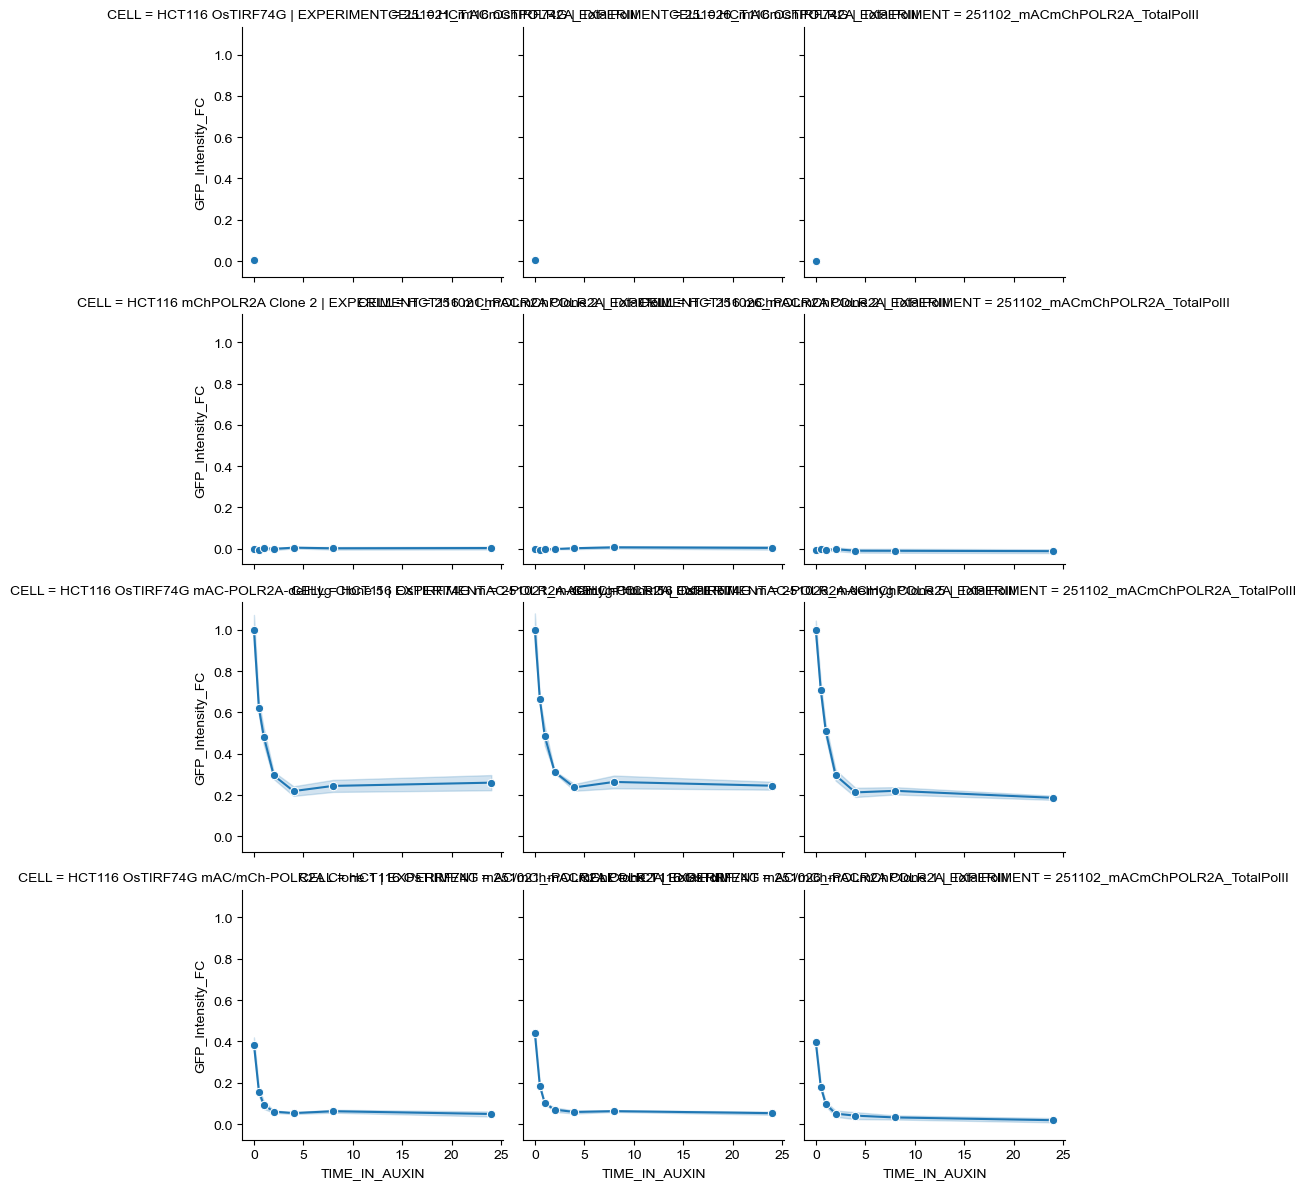

In [92]:
g = sns.FacetGrid(IntensitiesByWell,
                  col = 'EXPERIMENT',
                  row = 'CELL')

g.map_dataframe(sns.lineplot,
                x = 'TIME_IN_AUXIN',
                y = 'GFP_Intensity_FC',
                marker = 'o',
                errorbar = 'sd')

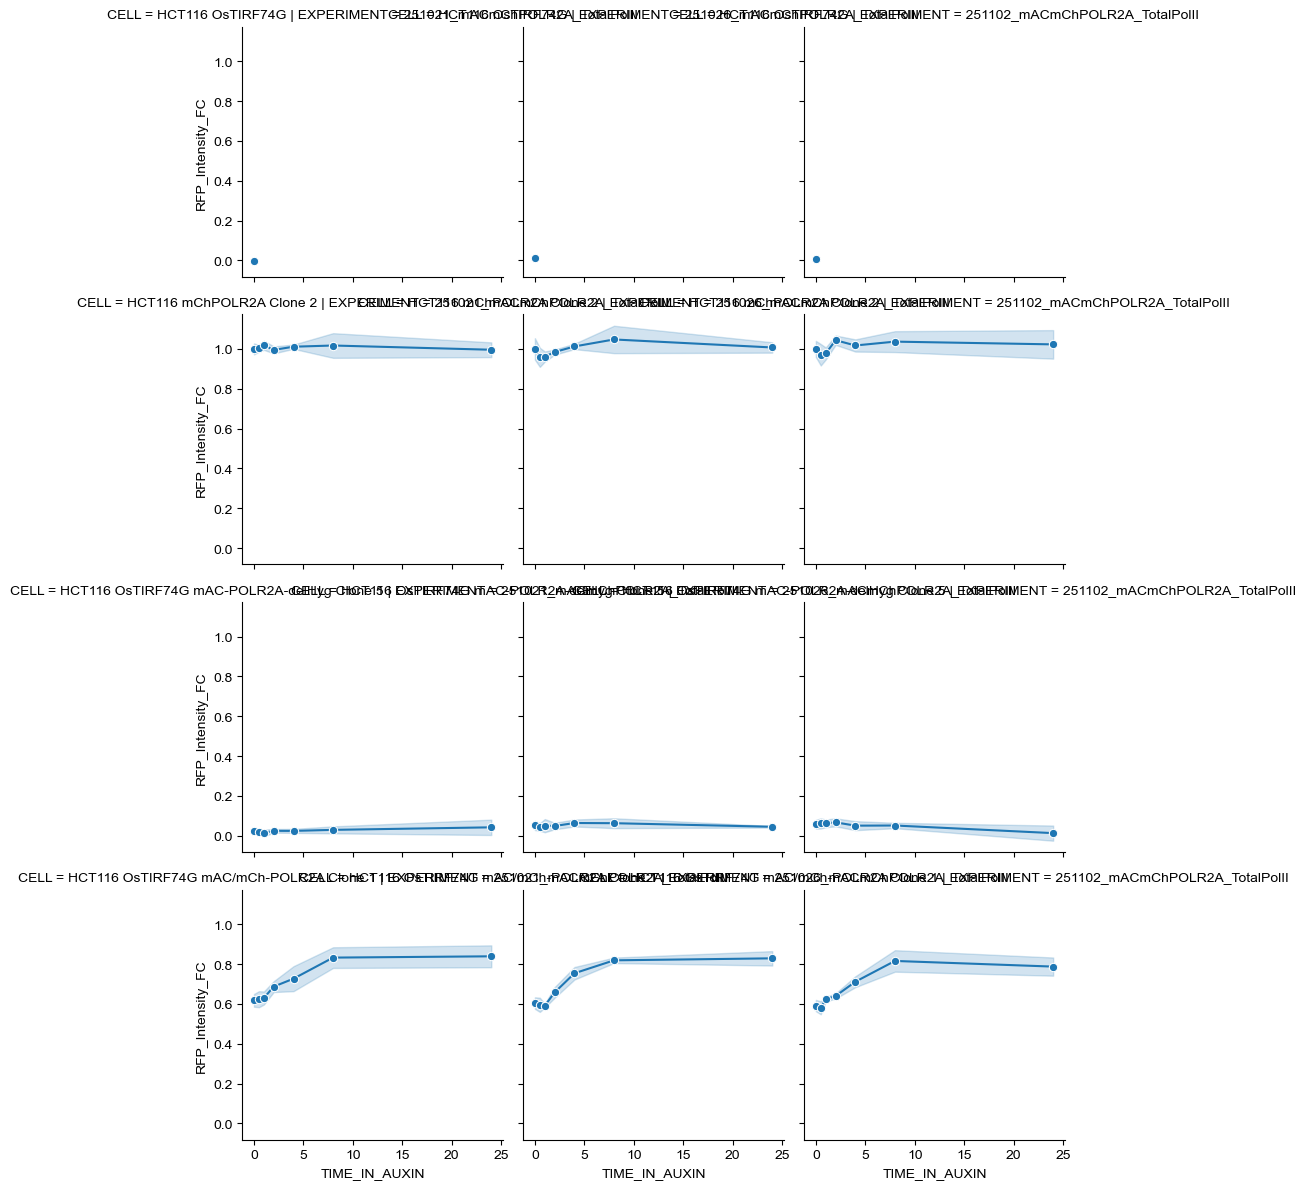

In [93]:
g = sns.FacetGrid(IntensitiesByWell,
                  col = 'EXPERIMENT',
                  row = 'CELL')

g.map_dataframe(sns.lineplot,
                x = 'TIME_IN_AUXIN',
                y = 'RFP_Intensity_FC',
                marker = 'o',
                errorbar = 'sd')

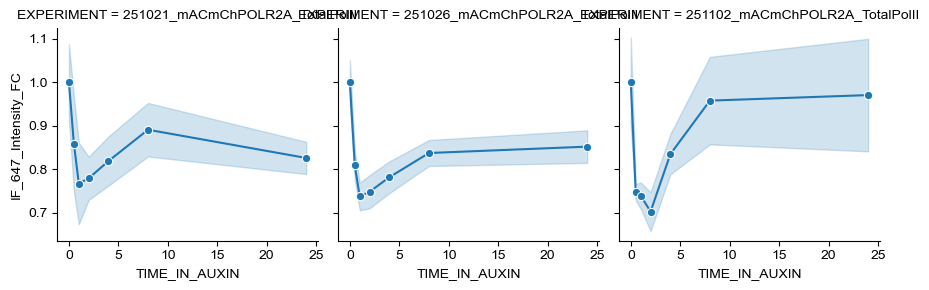

In [120]:
g = sns.FacetGrid(mACmCh_Total_IntensitiesByWell,
                  col = 'EXPERIMENT')

g.map_dataframe(sns.lineplot,
                x = 'TIME_IN_AUXIN',
                y = 'IF_647_Intensity_FC',
                marker = 'o',
                errorbar = 'sd')

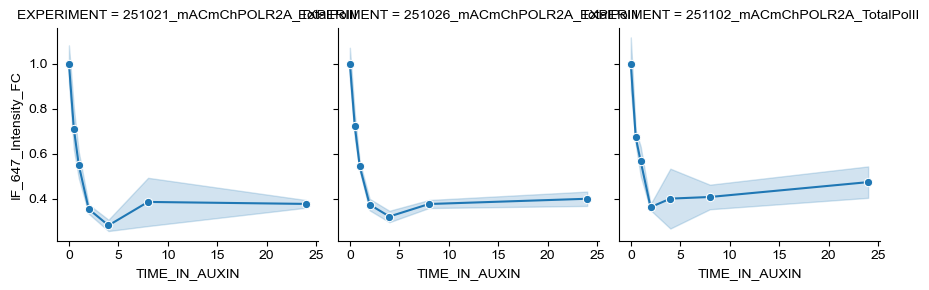

In [121]:
g = sns.FacetGrid(mACPOLR2A_Total_IntensitiesByWell,
                  col = 'EXPERIMENT')

g.map_dataframe(sns.lineplot,
                x = 'TIME_IN_AUXIN',
                y = 'IF_647_Intensity_FC',
                marker = 'o',
                errorbar = 'sd')

# Plots for manuscript

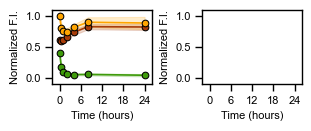

In [134]:
f, a = plt.subplots(ncols = 2, figsize = (3,1.5), layout = 'constrained')

sns.set_context('paper')

sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'), 
             x = 'TIME_IN_AUXIN', 
             y = 'GFP_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = 'xkcd:grass green', 
             legend = False)

sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'),
             x = 'TIME_IN_AUXIN', 
             y = 'RFP_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = 'xkcd:rust', 
             legend = False)

sns.lineplot(mACPOLR2A_Total_IntensitiesByWell, 
             x = 'TIME_IN_AUXIN', 
             y = 'IF_647_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = 'orange', 
             legend = False)


for i in range(2):
    a[i].set_xlabel('Time (hours)', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.75)
    a[i].set_ylim(-0.1,1.1)
    a[i].set_yticks([0, 0.5, 1])
    a[i].set_xticks(np.linspace(0,24,5))
    a[i].set_xlim(-2, 26)
    a[i].tick_params(axis='both', labelsize=8)

#plt.savefig('mACmChPOLR2A_GFP_RFP_TotalPolII.svg')

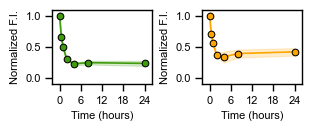

In [138]:
f, a = plt.subplots(ncols = 2, figsize = (3,1.5), layout = 'constrained')

sns.set_context('paper')

sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5"'), 
             x = 'TIME_IN_AUXIN', 
             y = 'GFP_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = 'xkcd:grass green', 
             legend = False)

sns.lineplot(mACPOLR2A_Total_IntensitiesByWell, 
             x = 'TIME_IN_AUXIN', 
             y = 'IF_647_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[1], 
             color = 'orange', 
             legend = False)


for i in range(2):
    a[i].set_xlabel('Time (hours)', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.75)
    a[i].set_ylim(-0.1,1.1)
    a[i].set_yticks([0, 0.5, 1])
    a[i].set_xticks(np.linspace(0,24,5))
    a[i].set_xlim(-2, 26)
    a[i].tick_params(axis='both', labelsize=8)

plt.savefig('mACPOLR2A_GFP_TotalPolII.svg')